# Stage 4 (Updated): Baseline Model Training — 10-Stock Multi-Asset Pipeline

Baseline RF and XGBoost models evaluated on the **pooled 10-stock modelling dataset**
(2,071 events × 50 features: 17 TS + 33 WorldQuant 101 alphas).

CV uses **MultiAssetPurgedKFold** — splits the *time axis* so all stocks at the
same event date go to the same fold, preventing cross-sectional alpha leakage.

Hyperparameter tuning is in notebook 09; this notebook is the untuned reference baseline.

In [ ]:
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score
from sklearn.base import clone
from xgboost import XGBClassifier

sys.path.append('../')
from src.cross_validation import MultiAssetPurgedKFold, cv_score
from src.modelling import train_and_evaluate

plt.style.use('seaborn-v0_8-darkgrid')
RNG = 42

## 1. Load the pooled 10-stock modelling dataset

In [ ]:
dataset = pd.read_parquet('../data/processed/pooled_modelling.parquet')

meta_cols = {'label', 't1', 'weight', 'ticker'}
ts_cols   = [c for c in dataset.columns if c not in meta_cols and not c.startswith('alpha')]
alpha_cols = [c for c in dataset.columns if c.startswith('alpha')]
feat_cols  = ts_cols + alpha_cols   # 17 TS + 33 alpha = 50 total

X = dataset[feat_cols]
y = dataset['label'].astype(int)
y_xgb = (y == 1).astype(int)
sample_weight = dataset['weight']
t1 = dataset['t1']

majority_baseline = float((y == y.mode()[0]).mean())
print(f'X shape        : {X.shape}')
print(f'TS features    : {len(ts_cols)}')
print(f'Alpha features : {len(alpha_cols)}')
print(f'Label dist     : {dict(y.value_counts().sort_index())}')
print(f'Majority base  : {majority_baseline:.4f}')
print(f'Tickers        : {sorted(dataset["ticker"].unique())}')
print(f'Date range     : {dataset.index.min().date()} -> {dataset.index.max().date()}')

## 2. Define baseline models (AFML recipe)

In [3]:
rf = RandomForestClassifier(
    n_estimators=500, max_depth=5, min_samples_leaf=10,
    class_weight='balanced_subsample',
    random_state=RNG, n_jobs=-1,
)
xgb = XGBClassifier(
    n_estimators=500, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RNG, eval_metric='logloss', n_jobs=-1,
)

## 3. MultiAssetPurgedKFold 5-fold CV (weighted fit + weighted scoring)

`MultiAssetPurgedKFold` splits on the *time axis* (unique event dates), not on rows.
All stocks at the same date land in the same fold — this prevents the alpha features
(which are cross-sectional) from leaking rank-information across the train/test boundary.

In [ ]:
pkf = MultiAssetPurgedKFold(n_splits=5, t1=t1, pct_embargo=0.01)
rf_results  = train_and_evaluate(rf,  X, y,     sample_weight, cv=pkf, scoring='accuracy')
xgb_results = train_and_evaluate(xgb, X, y_xgb, sample_weight, cv=pkf, scoring='accuracy')

print(f"RF  (weighted): mean={rf_results['mean_score']:.4f}  std={rf_results['std_score']:.4f}")
print(f"XGB (weighted): mean={xgb_results['mean_score']:.4f}  std={xgb_results['std_score']:.4f}")

### Weighted vs unweighted scoring (sanity check)

Same fits, two scoring paths: the new weighted one (default) and the legacy unweighted one (`score_with_weights=False`). Per-fold differences confirm the test-fold weights are flowing through to the metric.

In [5]:
rf_w   = cv_score(rf,  X, y,     sample_weight, scoring='accuracy', cv=pkf)
rf_u   = cv_score(rf,  X, y,     sample_weight, scoring='accuracy', cv=pkf,
                  score_with_weights=False)
xgb_w  = cv_score(xgb, X, y_xgb, sample_weight, scoring='accuracy', cv=pkf)
xgb_u  = cv_score(xgb, X, y_xgb, sample_weight, scoring='accuracy', cv=pkf,
                  score_with_weights=False)

compare = pd.DataFrame({
    'RF_weighted':    rf_w.values,
    'RF_unweighted':  rf_u.values,
    'XGB_weighted':   xgb_w.values,
    'XGB_unweighted': xgb_u.values,
}, index=[f'fold_{i+1}' for i in range(pkf.get_n_splits())]).round(4)
compare.loc['mean'] = compare.mean().round(4)
compare

,RF_weighted,RF_unweighted,XGB_weighted,XGB_unweighted
fold_1,0.6519,0.6667,0.5868,0.6154
fold_2,0.4928,0.5385,0.3857,0.4615
fold_3,0.5405,0.5385,0.5730,0.5385
fold_4,0.4362,0.4359,0.4607,0.4872
fold_5,0.4985,0.5385,0.6354,0.6667
mean,0.5240,0.5436,0.5283,0.5539


## 4. Per-fold scores (weighted)

In [6]:
fold_scores = pd.DataFrame({
    'RF':  rf_results['fold_scores'].values,
    'XGB': xgb_results['fold_scores'].values,
}, index=[f'fold_{i+1}' for i in range(pkf.get_n_splits())])
fold_scores

,RF,XGB
fold_1,0.651904,0.586826
fold_2,0.492848,0.385718
fold_3,0.540486,0.573031
fold_4,0.436166,0.460744
fold_5,0.498466,0.635410


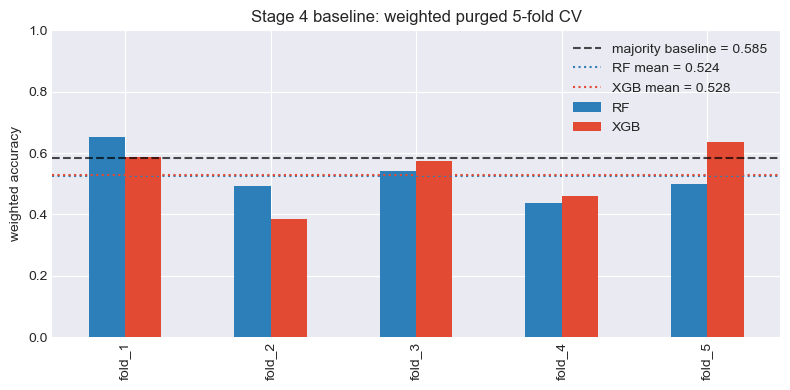

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
fold_scores.plot(kind='bar', ax=ax, color=['#2c7fb8', '#e34a33'])
ax.axhline(majority_baseline, color='k', linestyle='--', alpha=0.7,
           label=f'majority baseline = {majority_baseline:.3f}')
ax.axhline(rf_results['mean_score'],  color='#2c7fb8', linestyle=':',
           label=f"RF mean = {rf_results['mean_score']:.3f}")
ax.axhline(xgb_results['mean_score'], color='#e34a33', linestyle=':',
           label=f"XGB mean = {xgb_results['mean_score']:.3f}")
ax.set_ylabel('weighted accuracy')
ax.set_ylim(0, 1)
ax.set_title('Stage 4 baseline: weighted purged 5-fold CV')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Confusion matrices on a representative fold

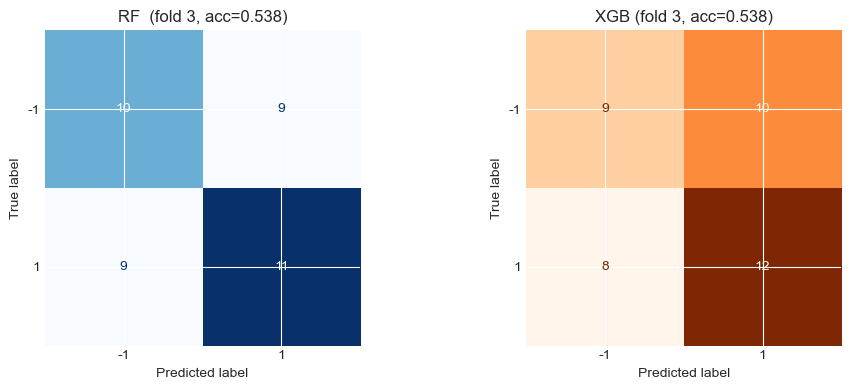

In [8]:
def representative_fold(scores):
    return int(np.argmin(np.abs(scores.values - scores.mean())))

fold_idx = representative_fold(rf_results['fold_scores'])
splits = list(pkf.split(X, y))
tr_idx, te_idx = splits[fold_idx]

X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
y_xgb_tr, y_xgb_te = y_xgb.iloc[tr_idx], y_xgb.iloc[te_idx]
sw_tr = sample_weight.iloc[tr_idx].values

rf_fold  = clone(rf).fit(X_tr,  y_tr,     sample_weight=sw_tr)
xgb_fold = clone(xgb).fit(X_tr, y_xgb_tr, sample_weight=sw_tr)

rf_pred  = rf_fold.predict(X_te)
xgb_pred = np.where(xgb_fold.predict(X_te) == 1, 1, -1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_te, rf_pred, labels=[-1, 1]), display_labels=[-1, 1]
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'RF  (fold {fold_idx + 1}, acc={accuracy_score(y_te, rf_pred):.3f})')
ConfusionMatrixDisplay(
    confusion_matrix(y_te, xgb_pred, labels=[-1, 1]), display_labels=[-1, 1]
).plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title(f'XGB (fold {fold_idx + 1}, acc={accuracy_score(y_te, xgb_pred):.3f})')
plt.tight_layout()
plt.show()

## 6. Comparison and persistence

In [9]:
comparison = pd.DataFrame({
    'mean_weighted_acc': [rf_results['mean_score'], xgb_results['mean_score']],
    'std_acc':           [rf_results['std_score'],  xgb_results['std_score']],
    'beats_baseline':    [rf_results['mean_score']  > majority_baseline,
                          xgb_results['mean_score'] > majority_baseline],
}, index=['RandomForest', 'XGBoost'])
comparison['majority_baseline'] = majority_baseline
comparison.round(4)

,mean_weighted_acc,std_acc,beats_baseline,majority_baseline
RandomForest,0.5240,0.0806,False,0.5846
XGBoost,0.5283,0.1022,False,0.5846


In [10]:
rf_final  = rf_results['fitted_clf']
xgb_final = xgb_results['fitted_clf']

os.makedirs('../models', exist_ok=True)
with open('../models/model_rf.pkl',  'wb') as f: pickle.dump(rf_final,  f)
with open('../models/model_xgb.pkl', 'wb') as f: pickle.dump(xgb_final, f)

cv_results_df = fold_scores.copy()
cv_results_df.loc['mean'] = comparison['mean_weighted_acc'].values
cv_results_df.loc['std']  = comparison['std_acc'].values
cv_results_df.to_parquet('../data/processed/cv_results.parquet')

print('Saved:')
print('  ../models/model_rf.pkl')
print('  ../models/model_xgb.pkl')
print('  ../data/processed/cv_results.parquet')

Saved:
  ../models/model_rf.pkl
  ../models/model_xgb.pkl
  ../data/processed/cv_results.parquet


## 7. Notes

- This notebook reports the **untuned** baseline. Notebook 09 sweeps   hyperparameters and applies the multiple-testing deflator.
- All scores in this notebook are **weighted accuracies** — both fit   and scoring use AFML-style sample weights.
- If a model's weighted CV mean is below the majority-class baseline,   that is reported honestly here; whether it beats baseline is read   off the `beats_baseline` column above.
- Dataset: 195 events × 17 features after the Stage 3 fixes (fracdiff   d* = 0.25, Corwin-Schultz floored at 0, Lempel-Ziv normalised).